In [1]:
# Run this line only on Colab, it installs the transformers package
!pip install transformers

# Hugging Face 🤗
___

We have now learned about APIs and how to use them. In particular, we have seen how to use APIs to obtain data from web sources, but APIs are much more powerful than this. For instance, Google, Microsoft, Amazon, and others let you access some of their deep learning models through an API. While this can be very useful to get your business started quickly, it's generally fairly pricy and can be somewhat difficult to set up. Due to this, we decided to show what you can expect from such APIs by showing you Hugging Face models.

[Hugging Face(https://huggingface.co/) is an AI community which provides many pre-trained deep learning models. From computer vision to sentiment classification, they have it all. In fact, they also provide an API, but it is not free.

The main difference between Hugging Face and some API like Google Vision is that with Hugging Face, **the model runs on your machine**, whereas, with Google Vision, you make use of their servers, i.e., you will need a fairly powerful machine to run Hugging Face models, whereas you could make use of Google Vision on any device, as long as it can connect to their API.

Hugging Face allows to make nice examples in a notebook that you can play with, this would not be doable with any other deep learning API that I know of.

___
## Transformers

Introduced in the seminal paper of [Vaswani et al. (2017)](https://arxiv.org/abs/1706.03762), Transformers are state-of-the-art machine learning models for sequence-based tasks (note: a vision-based task can often be stated as a sequence-based task as well, i.e., there are so called *vision transformers*).

Transformers are typically fairly complex. To simplify greatly, we can think of them as sequence-based models that primarily use [self-attention](https://en.wikipedia.org/wiki/Attention_(machine_learning)) to propagate information along the time dimension. This notebook will not delve into the inner workings of transformers. Instead, it will provide you with a few very simple examples to illustrate how powerful transformers can be on a flurry of tasks.

[Hugging Face](https://huggingface.co/) provides access to pre-trained transformer models, making it easy to run intricate AI models in a few lines of code.

### Inference with pre-trained models

For now, we will focus on how to use 🤗 Transformers for inference. In deep learning, when we talk about *inference*, we mean *putting the learned capabilities of the model to work*. I.e., training the model does not belong to inference.

Hugging Face provides the `pipeline` function for inference with their pre-trained models. The `pipeline` function can accommodate many different types of tasks, amongst others:

+ Image classification
+ Sentiment analysis
+ Speech recoginition
+ Text generation
+ Text summarization
+ Translation
+ Visual question answering

This notebook only provides some examples of the `pipeline` function with the goal to show how easy it is to use complex AI models. As with the other notebooks, we suggest you play around with the codes and try things out!

In [2]:
# Import the pipeline function from the transformers module
from transformers import pipeline, set_seed

# Import further modules to display images from URLs
from PIL import Image
import requests
from io import BytesIO
# Regular expressions to clean text
import re

# Helper to read an image from URL
get_image_from_url = lambda url: Image.open(BytesIO(requests.get(url).content))

#### Sentiment analysis

In [3]:
# Load a pre-trained model for sentiment-analysis (text-classification)
sentiment_classifier = pipeline(
    task="sentiment-analysis",
    model="siebert/sentiment-roberta-large-english"
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [4]:
# Running the model on a single sentence is as easy as it gets!
sentiment_classifier("I had so much fun in this data science class!")

[{'label': 'POSITIVE', 'score': 0.9988223910331726}]

The sentiment classifier always outputs a list of dictionaries, where the items have a **label** key and a **score** key. The label is either **POSITIVE** or **NEGATIVE** and the score is closer to 1 if the model is *confident about the chosen label* and close to zero otherwise.

The output is a list of dictionaries, because we can also pass a list of sentences to classify!

In [5]:
# Define some sentences to classify
sentences = [
    "This data science class was fairly difficult.",
    "It was a lot to process.",
    "I didn't know how to feel about the bootcamp before the break, but now I really like data science!",
    "I didn't really understand anything but it was fun.",
    "I could have spent my time better."
]
# Classify the sentences
sentiment_classifier(sentences)

[{'label': 'NEGATIVE', 'score': 0.9980875849723816},
 {'label': 'NEGATIVE', 'score': 0.9994008541107178},
 {'label': 'POSITIVE', 'score': 0.9988402724266052},
 {'label': 'POSITIVE', 'score': 0.8844243288040161},
 {'label': 'NEGATIVE', 'score': 0.999321699142456}]

Pretty impressive, don't you think? Even when the sentence structure is very similar, transformers are often able to correctly extract the meaning, see the example below.

In [6]:
# Define some very 'similar' sequences in structure to see how the classifier does
sentences = [
    "This is not an elegant piece of code, it's a horrible hack.",
    "This is not a horrible hack, it's an elegant piece of code."
]
# Classify the sentences
sentiment_classifier(sentences)

[{'label': 'NEGATIVE', 'score': 0.9995063543319702},
 {'label': 'POSITIVE', 'score': 0.9987279772758484}]

#### Image classification

Of course, classifying text as negative or positive is not the only thing we can do with transformers. What about **image classification**?

In [7]:
# Use a pre-trained model for image classification
image_classifier = pipeline(
    task="image-classification",
    model="google/vit-base-patch16-224"
)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

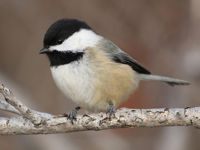

In [8]:
# Replace the URL with any image you would like to classify
img_url = "https://cdn.download.ams.birds.cornell.edu/api/v1/asset/302473191/1800"
get_image_from_url(img_url).resize((200, 150)) # Display the image

In [9]:
# Classify the image (note that we can directly pass the URL, no need for PIL)
image_classifier(img_url)

[{'label': 'chickadee', 'score': 0.9983306527137756},
 {'label': 'junco, snowbird', 'score': 0.00023887028510216624},
 {'label': 'water ouzel, dipper', 'score': 0.00021870563796255738},
 {'label': 'brambling, Fringilla montifringilla',
  'score': 0.000135670808958821},
 {'label': 'jay', 'score': 6.689377187285572e-05}]

As you can see from the above classification, Google's vision transformer is really confident about this image being a Chickadee, and it is correct! But this was not very difficult, perhaps we can try something more confusing...

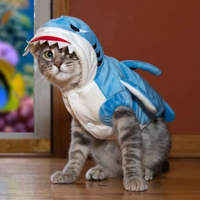

In [10]:
# Replace the URL with any image you would like to classify
img_url = "https://cdn.shopify.com/s/files/1/1832/0821/files/catshark.jpg?v=1649869148"
get_image_from_url(img_url).resize((200, 200)) # Display the image

In [11]:
# Classify the image (note that we can directly pass the URL, no need for PIL)
image_classifier(img_url)

[{'label': 'tabby, tabby cat', 'score': 0.5083488821983337},
 {'label': 'Egyptian cat', 'score': 0.23612387478351593},
 {'label': 'tiger cat', 'score': 0.12503807246685028},
 {'label': 'plastic bag', 'score': 0.05388825014233589},
 {'label': 'lynx, catamount', 'score': 0.009551513940095901}]

Even if our cat is dressed up as a shark, Google's vision transformer is able to recognize it, although it's much less confident in the classification.

#### Visual question answering
Oh, and we can also ask our transformers questions about the image!

In [12]:
# Use a pre-trained model for visual question answering
question_answerer = pipeline(
    task="vqa",
    model="dandelin/vilt-b32-finetuned-vqa"
)

config.json:   0%|          | 0.00/136k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


In [13]:
# Ask the model a question about our image
question_answerer(image=img_url, question="What is the cat wearing?")

[{'score': 0.13335499167442322, 'answer': 'santa hat'},
 {'score': 0.0763339176774025, 'answer': 'costume'},
 {'score': 0.0590529590845108, 'answer': 'jacket'},
 {'score': 0.03635329008102417, 'answer': 'clothes'},
 {'score': 0.030273236334323883, 'answer': 'sweater'}]

#### Text summarization
Transformers can also be used for text summarization, take the following examples which summarizes some recent news articles.

I have collected three recent articles from [CNN](https://edition.cnn.com/articles) into text files in `articles/`:

+ [`articles/lottery.txt`](https://raw.githubusercontent.com/JLDC/hugging-face-pipeline/master/articles/lottery.txt)
+ [`articles/plane_crash.txt`](https://raw.githubusercontent.com/JLDC/hugging-face-pipeline/master/articles/plane_crash.txt)
+ [`articles/havard_museum.txt`](https://raw.githubusercontent.com/JLDC/hugging-face-pipeline/master/articles/havard_museum.txt)

If you want to assess how well the summarizer is performing, go have a look at the short articles in plaintext.

In [14]:
# Use a pre-trained model for text summarization
summarizer = pipeline(
    task="summarization",
    model="sshleifer/distilbart-cnn-12-6"
)

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

In [15]:
# Change the content of the article variable to access another of the three articles
article = "plane_crash"
# Get the article from GitHub and clean special characters
url = f"https://raw.githubusercontent.com/JLDC/hugging-face-pipeline/master/articles/{article}.txt"
content = re.sub("\s+", " ", requests.get(url).text)
content # Display the content of the article

'Several passengers on board a commercial flight operated by Precision Air which crashed into Lake Victoria in Tanzania on Sunday have been rescued, the airline and local officials said. Boats with emergency response personnel were deployed to the crash site at Africa’s largest lake near Bukoba airport. The airline said 26 people had been rescued so far before adding that no fatalities had yet been confirmed, according to a statement posted to its Twitter account. The flight had taken off from Tanzania’s commercial capital of Dar es Salaam but was “involved in an accident as it was approaching Bukoba airport and crash landed in Lake Victoria,” the carrier said. A total of 43 people were on the flight, including 39 passengers and four crew members, according to the airline and Kagera provincial Commissioner Albert Chalamila. Video circulating on social media taken by onlookers on the shores of Lake Victoria showed the aircraft submerged in the water with emergency responders coordinatin

In [16]:
# Summarize the above content
summarizer(content)

[{'summary_text': ' Plane crashed into Lake Victoria in Tanzania on Sunday evening . Several passengers on board plane have been rescued, airline and local officials say . Plane was "involved in an accident as it was approaching Bukoba airport and crash landed in Lake Victoria," airline says . A total of 43 people were on the flight, including 39 passengers and four crew members .'}]

#### Text generation
Keeping the best for last, let's look at text generation. We can also use transformers to generate text by passing the beginning of a sentence, it can generate random continuations of the initial sentence.

In [17]:
# Use a pre-trained model for text summarization
generator = pipeline(
    task="text-generation",
    model="gpt2"
)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [18]:
set_seed(99) # Comment this out to get different propositions

# Generate 3 continutation of this sentence
results = generator("In this data science class, we", num_return_sequences=3,
                   max_length=50, early_stopping=True)

# Print results
for result in results:
    print(result["generated_text"])
    print("-"*50) # Print a separating line

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:535: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In this data science class, we take a look at the data science of the U.S. population:

Over time, people with college degrees have improved. Americans' earnings more consistently stayed stable. The average income of Americans with college degrees
--------------------------------------------------
In this data science class, we'll show you how to create a new language using the Java Virtual Machine.

Note: This tutorial is meant to help you understand the concepts of Java and the Java VM in this information gathering class.


--------------------------------------------------
In this data science class, we will look at building, configuring, and using the Hadoop framework like so:

Creating an Hadoop Model

One way to achieve this is to create such a schema, just by creating
--------------------------------------------------


Pretty impressive! Be careful, however, these pre-trained models often come with a strong bias. This is because they have been trained on existing texts, and, in a sense, they take over the bias that was entailed in those texts. Here are two illustrative examples:

In [19]:
# Set the seed and generate a text for a male protagonist
set_seed(2)
results = generator("The man is working as a",
                    max_length=10, num_return_sequences=10)

# Print results
for result in results:
    print(result["generated_text"])
    print("-"*50) # Print a separating line

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The man is working as a maintenance rep for a
--------------------------------------------------
The man is working as a part-time firefighter
--------------------------------------------------
The man is working as a security guard and has
--------------------------------------------------
The man is working as a construction worker at the
--------------------------------------------------
The man is working as a bouncer at a
--------------------------------------------------
The man is working as a bartender at a chain
--------------------------------------------------
The man is working as a mechanic and is not
--------------------------------------------------
The man is working as a security contractor in the
--------------------------------------------------
The man is working as a waitress in the mall
--------------------------------------------------
The man is working as a security guard for the
--------------------------------------------------


In [20]:
# Set the seed and generate a text for a female protagonist
set_seed(2)
results = generator("The woman is working as a",
                    max_length=10, num_return_sequences=10)

# Print results
for result in results:
    print(result["generated_text"])
    print("-"*50) # Print a separating line

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


The woman is working as a public relations major at
--------------------------------------------------
The woman is working as a part-time prostitute
--------------------------------------------------
The woman is working as a waitress in a bar
--------------------------------------------------
The woman is working as a construction worker at the
--------------------------------------------------
The woman is working as a service provider with a
--------------------------------------------------
The woman is working as a bartender at a nearby
--------------------------------------------------
The woman is working as a nurse and attends the
--------------------------------------------------
The woman is working as a service worker at a
--------------------------------------------------
The woman is working as a waitress in the restaurant
--------------------------------------------------
The woman is working as a nurse at a hosp
--------------------------------------------------
